# General notebook

In [1]:
using Revise
Revise.retry() # Just in case if only Revise is not sufficient. 
include("lattice_protein.jl")

Imports done, importing hamiltonian path
Starting backtracking
Calculation of all conformations
Step 1: Exploration from the corner (node 1)
Step 2: Exploration from the center of the face (node 5)
hamiltonian path imported, importing metropolis
metropolis imported, importing benchmark
benchmark imported, importing visualization
visualization imported, importing tree
tree imported, importing lattice_protein


## Hamiltonian paths

In [2]:
println("We find $(length(PATHS)) unique paths.")
println(first(PATHS))

We find 103346 unique paths.
Int8[1, 2, 3, 6, 5, 4, 7, 8, 9, 18, 17, 16, 13, 14, 15, 12, 11, 10, 19, 20, 21, 24, 23, 22, 25, 26, 27]


Contact map for the first path:
Path visualization for the 75005:


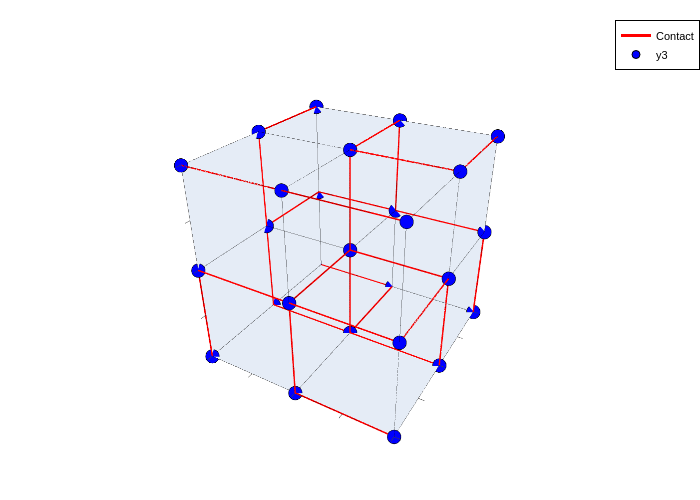

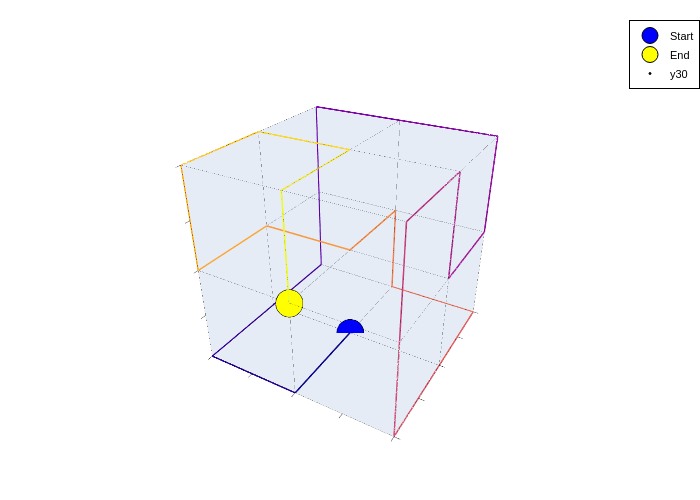

In [3]:
println("Contact map for the first path:")
liste_contact = contact_map(PATHS[75005])
display(plot_cube_ctc_map(x, y, z, lx, ly, lz, liste_contact))

println("Path visualization for the 75005:")
display(plot_cube_path(x, y, z, lx, ly, lz, PATHS[75005]))

## Metropolis general results

Attention : si on veut changer de matrice (MJ*5 ou MJ_1996) il faut restart le kernel et modifier la ligne const dans le ficher metropolis.jl. 

MJ*5

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:42


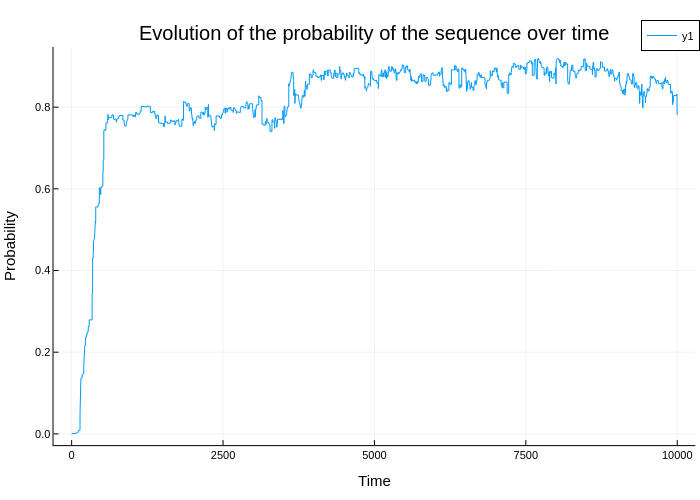

In [4]:
# with all the data
seq = generate_seq()
print(matrix_name)
target_number = 75005
all_ctc_maps = all_contact_maps(PATHS)
plot_probability(seq, target_number, all_ctc_maps, 10000)

MJ*5

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:03


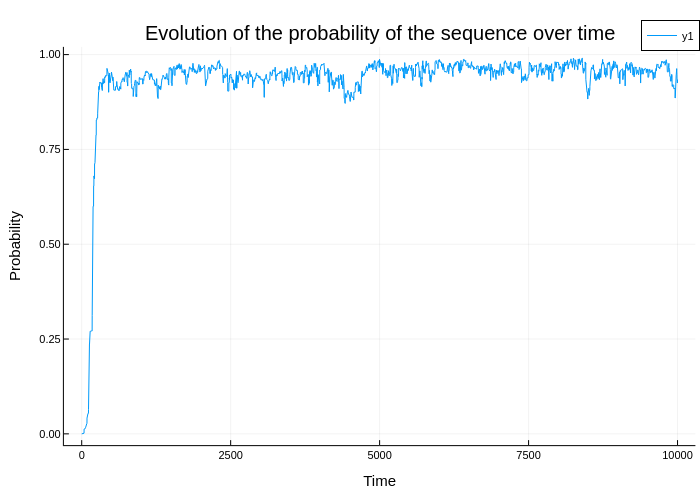

In [5]:
# with few data
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
print(matrix_name)

all_ctc_maps = all_contact_maps(paths_reduced)
plot_probability(seq, target_number, all_ctc_maps, 10000)

Testing beta = 10


algo (β=10) 100%|████████████████████████████████████████| Time: 0:00:01


Testing beta = 50


algo (β=50) 100%|████████████████████████████████████████| Time: 0:00:01


Testing beta = 100


algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:01


Testing beta = 1000


algo (β=1000) 100%|██████████████████████████████████████| Time: 0:00:01


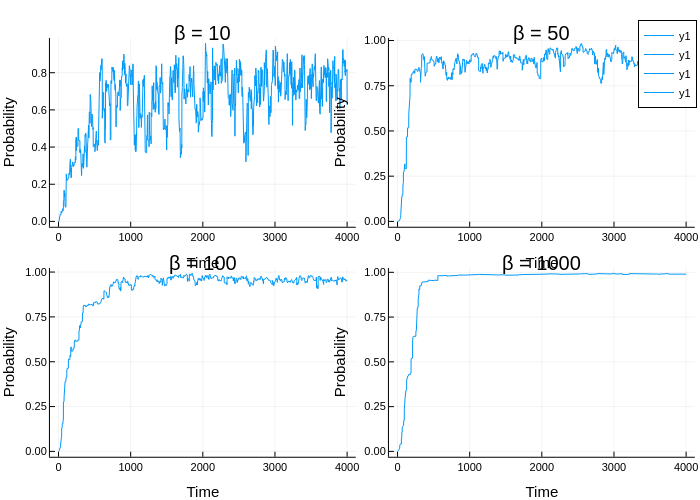

Dict{Float64, Tuple{Vector{Int64}, Vector{Float64}}} with 4 entries:
  50.0   => ([14, 15, 15, 19, 19, 16, 15, 15, 3, 16  …  4, 19, 18, 16, 3, 19, 2…
  10.0   => ([8, 20, 14, 16, 15, 12, 12, 18, 12, 15  …  16, 11, 15, 18, 5, 19, …
  1000.0 => ([9, 17, 6, 19, 18, 16, 16, 16, 6, 14  …  13, 18, 18, 15, 2, 16, 1,…
  100.0  => ([17, 19, 11, 15, 14, 17, 19, 17, 19, 10  …  15, 10, 18, 16, 5, 16,…

In [6]:
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
all_ctc_maps = all_contact_maps(paths_reduced)


benchmark_beta()

## Further observations

### Chain evolution

ici

Multi-init 100%|█████████████████████████████████████████| Time: 0:00:12


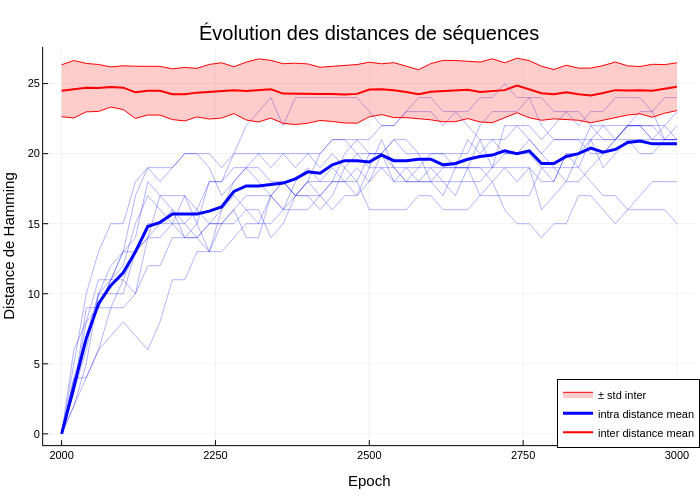

In [7]:
paths_reduced = reduce_data(PATHS, 10)
beta = 100.0

seq_over_time = multi_init_seq_over_time(target_number, all_ctc_maps, epochs=3000, beta=beta, threshold=2000, step=20, runs=10)
plot_distances_inter_intra(seq_over_time, beta=beta)

### All proba

In [8]:
final_seq, p_struct_time_t, p_final,_=algo_show_probability_distribution(seq, target_number, all_ctc_maps, 10000, 100)
show_sorted_indices(p_final)

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:03


structure 1234 : 0.9344704552415174
structure 5072 : 0.014731381449218844
structure 1233 : 0.011472811408375277
structure 7660 : 0.003818967166569552
structure 5084 : 0.0036327139400430587
structure 5082 : 0.003632713940043056
structure 2332 : 0.0026911806773083787
structure 1558 : 0.002559930246903484
structure 7665 : 0.001715972560952376
structure 5097 : 0.0014049195070896892
structure 9830 : 0.0012092254259872654
structure 2732 : 0.0011502508060535013
structure 5133 : 0.001150250806053499
structure 4816 : 0.0009900300436595979
structure 1236 : 0.0009900300436595946
structure 10325 : 0.0007710361732663162
structure 529 : 0.0006312710267886893
structure 5179 : 0.0006004835755161857
structure 2735 : 0.0005168410031590194
structure 1235 : 0.0004676570788335261


### Mutations on the cube

In [9]:
# Mutations en fonction de la position
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234

all_ctc_maps = all_contact_maps(paths_reduced)

beta = 100

_, _, saved_seq = algo(seq, target_number, all_ctc_maps, 10000, beta, 2000, 200)
println("On a sauvegardé $(length(saved_seq)) structures.")

n_mutations_per_position = amount_of_mutations(saved_seq)
n_mutations_per_position


algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:03


On a sauvegardé 41 structures.


Dict{Int64, Int64} with 27 entries:
  5  => 20
  16 => 10
  20 => 10
  12 => 25
  24 => 22
  8  => 31
  17 => 29
  1  => 33
  19 => 27
  22 => 9
  23 => 21
  6  => 23
  11 => 23
  9  => 29
  14 => 5
  3  => 37
  7  => 17
  25 => 5
  13 => 20
  ⋮  => ⋮

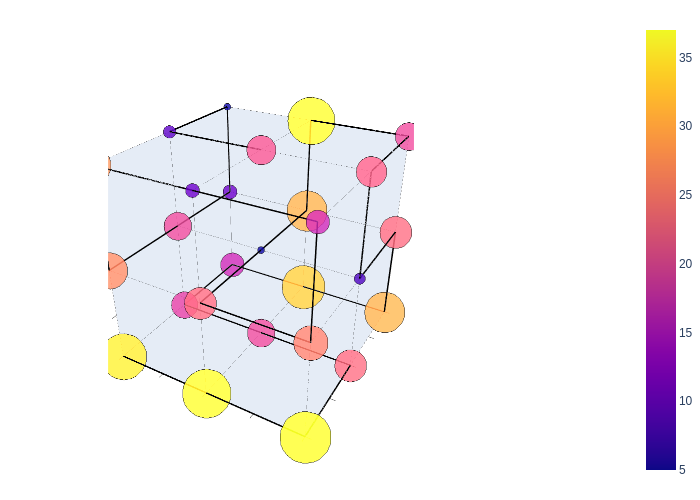

In [10]:
plot_cube_with_mutations_on_sphere(x, y, z, lx, ly, lz, PATHS[target_number], n_mutations_per_position)

In [11]:
beta = 100
target_number = 1234
epoch_start, epoch_stop, step = 2000, 10000, 200

paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
all_ctc_maps = all_contact_maps(paths_reduced)

_, _, saved_seq = algo(seq, target_number, all_ctc_maps, epoch_stop, beta, epoch_start, step)
println("On a sauvegardé $(length(saved_seq)) structures.")

plot_gif_cube_with_mutations(x, y, z, lx, ly, lz, PATHS[target_number], saved_seq)


algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:03


On a sauvegardé 41 structures.


┌ Info: Saved animation to /home/gabriel/Documents/S2/Projet_BIM/pBIM/figures/mutations.gif
└ @ Plots /home/gabriel/.julia/packages/Plots/xC48f/src/animation.jl:156


GIF sauvegardé : ../figures/mutations.gif


## Tree generation

### Creating the tree

In [12]:
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
all_ctc_maps = all_contact_maps(paths_reduced)
beta = 100
number_of_nodes = 3
distance_btw_nodes = 50

root_seq,p_struct_time_t,_ = algo(seq, target_number, all_ctc_maps, 5000, beta, 10000, 200, true)
proba_final_root = p_struct_time_t[end]
println("----------- Generating the root sequence : -----------")
println("Probability of the root sequence: $proba_final_root")
println()

newick, seq_dict = create_genealogy(root_seq, distance_btw_nodes, number_of_nodes, target_number, all_ctc_maps, beta=100 )

println("----------- Generated genealogy : -----------")
println(newick)
println()

# Charger l'arbre dans TreeTools
tree = parse_newick_string(newick)

println("----------- Sequences in the genealogy : -----------")
for node in nodes(tree)
    name = label(node)
    println("$name : " * join([aa_idx[acid] for acid in seq_dict[name]], " "))
end

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:03


----------- Generating the root sequence : -----------
Probability of the root sequence: 0.9387963237343516

----------- Generated genealogy : -----------
(((N4:50,N5:50)N3:50,(N7:50,N8:50)N6:50)N2:50,((N11:50,N12:50)N10:50,(N14:50,N15:50)N13:50)N9:50)N1;

----------- Sequences in the genealogy : -----------
N1 : TRP TYR GLU ARG PRO VAL ASP GLY GLU GLU ASP LYS ILE TYR ARG LEU ASN LYS SER PHE ARG MET ARG CYS PHE SER LEU
N6 : ASP VAL GLU LYS THR GLU GLU GLY GLU SER VAL ARG TRP TRP ILE LEU ASN LYS ASP ASP HIS MET LYS PHE PHE ASP ILE
N8 : CYS CYS GLN LYS ALA PRO GLU CYS GLU GLN TRP CYS CYS GLU ARG ALA GLU LYS GLU ASP ARG MET ARG VAL MET ASP LEU
N2 : THR ASP GLU LYS THR PRO GLU ASN GLU ASP LEU ARG ILE TRP MET MET ASN LYS GLY ASP HIS MET ARG PHE PHE ASN VAL
N14 : GLN ALA ASP ARG PHE TRP ASP MET GLU PHE ASP LYS LYS GLN CYS PHE GLU LYS TYR GLU ARG VAL ASN PHE LEU LYS PHE
N9 : MET GLU ASP ARG SER GLY ASP LEU GLU PHE GLU LYS PHE MET ALA VAL ASP LYS CYS GLU ARG LEU ARG MET CYS GLU TYR
N3 : LEU VA

In [13]:
N1= seq_dict["N1"]
N3 = seq_dict["N3"]
println(hamming_distance(N1,N3))

19


In [14]:
simple_print_distance_matrix(seq_dict)

      N1    N6    N8    N2    N14   N9    N3    N11   N4    N7    N12   N13   N15   N10   N5    
N1    0     19    20    19    20    20    19    21    25    22    24    18    21    22    20    
N6    19    0     20    13    24    25    15    22    19    17    23    23    26    25    20    
N8    20    20    0     19    23    23    19    21    20    21    24    20    26    23    19    
N2    19    13    19    0     24    24    15    22    19    18    24    25    27    26    17    
N14   20    24    23    24    0     18    22    21    21    25    20    16    16    20    22    
N9    20    25    23    24    18    0     22    21    22    23    21    17    21    18    21    
N3    19    15    19    15    22    22    0     21    16    21    23    23    26    23    14    
N11   21    22    21    22    21    21    21    0     22    22    24    23    25    21    22    
N4    25    19    20    19    21    22    16    22    0     20    21    21    23    24    19    
N7    22    17    21    18    

In [15]:
p = plot_distance_matrix(seq_dict)
savefig(p, "../figures/distance_matrix.svg")

"/home/gabriel/Documents/S2/Projet_BIM/pBIM/figures/distance_matrix.svg"

In [16]:
tree


                                                   ________________________ N4
                          ________________________|
                         |                        |________________________ N5
  _______________________|
 |                       |                         ________________________ N7
 |                       |________________________|
 |                                                |________________________ N8
_|
 |                                                 ________________________ N11
 |                        ________________________|
 |                       |                        |________________________ N12
 |_______________________|
                         |                         ________________________ N14
                         |________________________|
                                                  |________________________ N15


### Fitch reconstruction

In [17]:
result_fitch = fitch_reconstruction(tree, seq_dict)

for (name, seq) in sort(collect(result_fitch))
    println("$name : " * join([aa_idx[acid] for acid in seq], " "))
end
println(typeof(result_fitch))

N1 : GLN LEU ASP GLN SER LEU GLU CYS GLU GLN VAL LYS LEU LEU CYS PHE ASP LYS ASP ASP ARG LEU ARG LEU LEU ASP VAL
N10 : PHE TRP ASP GLN SER LEU LYS CYS GLU GLU VAL LYS VAL LEU MET PHE ASP LYS ASP GLU ARG VAL ASN PHE LEU GLU PHE
N11 : PHE TRP GLN GLU PRO LEU LYS CYS GLU GLU LEU SER VAL LEU MET PHE ASN LYS ASP GLU ARG PHE LYS MET MET GLU PHE
N12 : LYS GLY ASP GLN SER ALA LYS LYS GLU ARG VAL LYS ALA LEU PHE VAL ASP ARG THR ASP LYS VAL ASN PHE LEU ARG LEU
N13 : GLN LEU ASP ARG ILE LEU ASP MET GLU PHE ASP LYS LYS GLN CYS PHE ASP LYS MET GLU ARG VAL ASN PHE LEU ALA PHE
N14 : GLN ALA ASP ARG PHE TRP ASP MET GLU PHE ASP LYS LYS GLN CYS PHE GLU LYS TYR GLU ARG VAL ASN PHE LEU LYS PHE
N15 : TRP LEU GLY ARG ILE LEU ASP MET ASP PHE ASP LYS LYS GLU CYS LEU ASP ARG MET GLU LYS VAL ASN PRO VAL ALA PRO
N2 : CYS CYS ASP LYS SER PRO GLU CYS GLU GLN VAL LYS LEU PHE CYS PHE ASP LYS ASP ASP SER LEU ARG LEU ILE ASP VAL
N3 : CYS CYS ASP LYS SER THR GLU CYS GLU ASP ILE LYS MET PHE CYS PHE ASP LYS ASP ASP SER L

In [18]:
root_name_reconstructed, root_seq_reconstructed = first(sort(collect(result)))
print("$(join([aa_idx[acid] for acid in root_seq_reconstructed], " "))")

UndefVarError: UndefVarError: `result` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

### Consensus from the leaves

In [19]:
n_aa = 20

result_consensus, result_PWM = consensus_from_leaves_reconstruction(tree, seq_dict, n_aa; pseudo_count=1.0)

print("$(join([aa_idx[acid] for acid in result_consensus], " "))")

KeyError: KeyError: key "N1" => [1, 1, 16, 19, 12, 5, 15, 1, 15, 3, 6, 19, 2, 3, 1, 3, 16, 19, 16, 16, 18, 6, 14, 2, 2, 15, 3] not found

## Reconstruction error

In [20]:
# Result for the reconstruction above
println("Reconstruction Error (Hamming): $(reconstruction_error_hamming(result, seq_dict))")
println("Reconstruction Error (Probability): $(reconstruction_error_prob_folding(result, seq_dict, all_ctc_maps, target_number))")

UndefVarError: UndefVarError: `result` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [21]:
# generating values for the reconstruction error plots
distance_btw_nodes = 0:5:40
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
all_ctc_maps = all_contact_maps(paths_reduced)
number_of_nodes = 4

root_seq,_,_ = algo(seq, target_number, all_ctc_maps, 5000, 100, 10000, 200, true)

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:02


([8, 1, 8, 16, 1, 16, 14, 3, 6, 6  …  5, 2, 2, 6, 19, 1, 14, 15, 5, 15], [1.576662603081284e-7, 1.576662603081284e-7, 1.627213772932009e-7, 1.6373693276849052e-7, 2.6345319990509987e-7, 2.6345319990509987e-7, 2.5495885438013387e-6, 2.9773818606294403e-6, 4.588729393781533e-6, 4.588729393781533e-6  …  0.9570852286802697, 0.9570852286802697, 0.9570852286802697, 0.9570852286802697, 0.9570852286802697, 0.9570852286802697, 0.9570852286802697, 0.9570852286802697, 0.9570852286802697, 0.971696005529482], Dict{Int64, Vector{Int64}}())

1 2 3 4 5 6 7 8 9 10 
1 2 3 4 5 6 7 8 9 10 
1 2 3 4 5 6 7 8 9 10 
1 2 3 4 5 6 7 8 9 10 
1 2 3 4 5 6 7 8 9 10 
1 2 3 4 5 6 7 8 9 10 
1 2 3 4 5 6 7 8 9 10 
1 2 3 4 5 6 7 8 9 10 
1 2 3 4 5 6 7 8 9 10 
1 2 3 4 5 6 7 8 9 10 
1 2 3 4 5 6 7 8 9 10 
1 2 3 4 5 6 7 8 9 10 
1 2 3 4 5 6 7 8 9 10 
1 2 3 4 5 6 7 8 9 10 
1 2 3 4 5 6 7 8 9 10 
1 2 3 4 5 6 7 8 9 10 
1 2 3 4 5 6 7 8 9 10 
1 2 3 4 5 6 7 8 9 10 
1 2 3 4 5 6 7 8 9 10 
1 2 3 4 5 6 7 8 9 10 


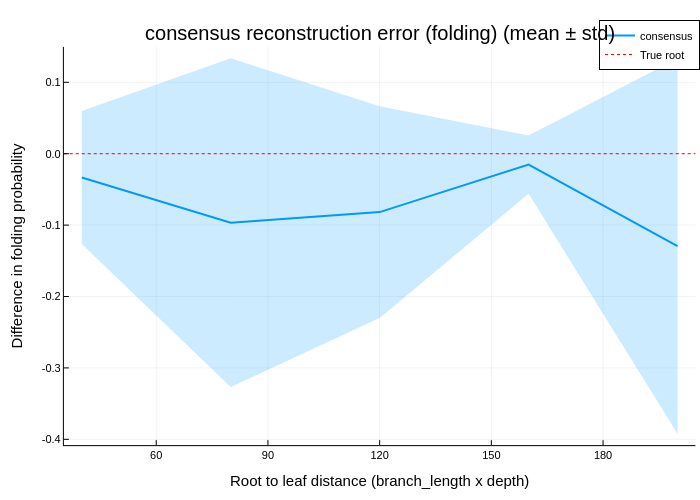

In [22]:
root_to_leaf_distances = [40, 80, 120, 160, 200]  # branch_length × profondeur
tree_depth = 2                                    # branch_length sera 20, 40, 60, 80, 100
n_trees = 10


hamming_fitch = plot_reconstruction_error_hamming(root_seq, root_to_leaf_distances, tree_depth, n_trees, target_number, all_ctc_maps, :fitch)
hamming_consensus = plot_reconstruction_error_hamming(root_seq, root_to_leaf_distances, tree_depth, n_trees, target_number, all_ctc_maps, :consensus)

proba_fitch = plot_reconstruction_error_proba(root_seq, root_to_leaf_distances, tree_depth, n_trees, target_number, all_ctc_maps, :fitch)
proba_consensus = plot_reconstruction_error_proba(root_seq, root_to_leaf_distances, tree_depth, n_trees, target_number, all_ctc_maps, :consensus)

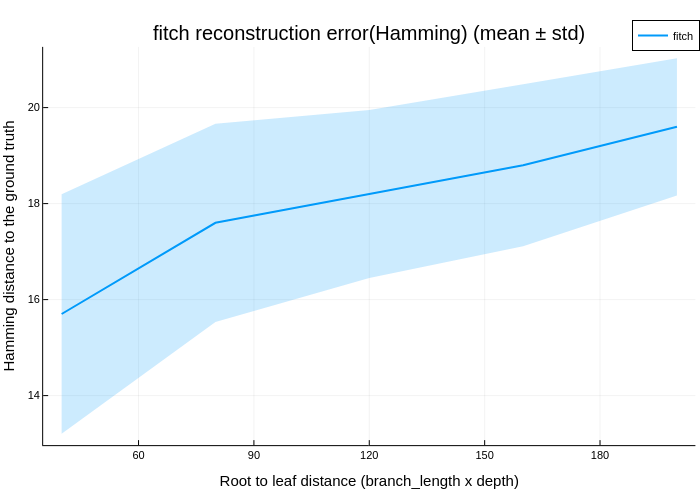

In [23]:
plot(hamming_fitch)


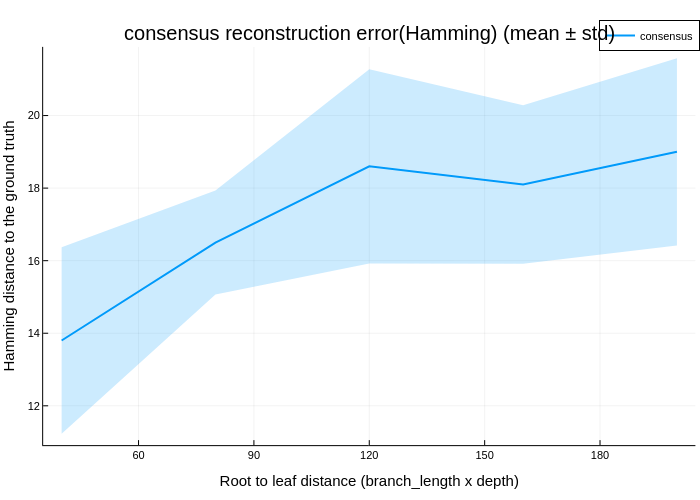

In [24]:
plot(hamming_consensus)


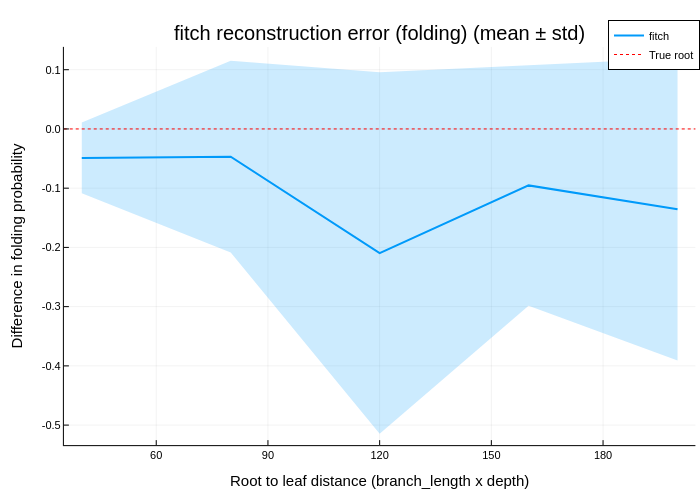

In [25]:
plot(proba_fitch)


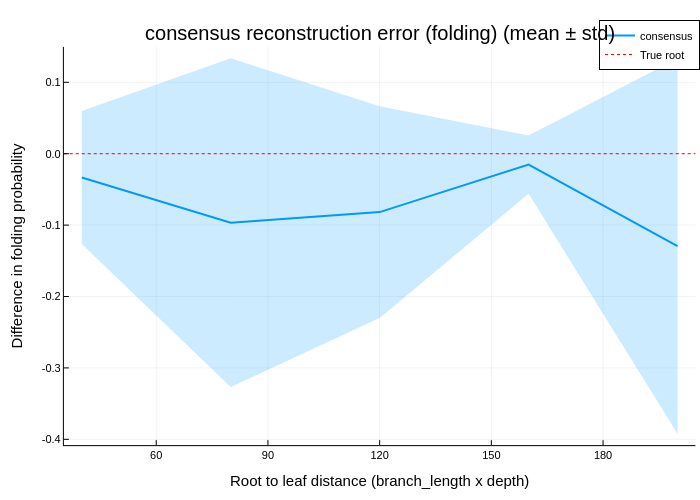

In [26]:
plot(proba_consensus)

In [ ]:
#Rapport log pour les probas plutot que la différence
#rajouter la proba des feuilles sur les graphiques pour montrer qu'elles se replient aussi bien que la racine
#essayer de faire ces graphes avec des temps qui commencent plus bas et qui augmentent logarithmiquement
#essayer de mélanger consensus et fitch dans le meme plot avec boite a moustache un peu décalé en x avec un leger bruit